# Sentinela Verde — modelo de impacto de data centers

**Frente:** `modelo-impacto-score/` · **Data:** 2026-09-10

Este notebook responde três perguntas, nesta ordem:

1. **Quanto** cada data center impactou o território ao redor? *(camada 1 — medição)*
2. **O que explica** o tamanho desse impacto? *(camada 2 — explicação)*
3. Dado um site novo, **que faixa esperar**? *(camada 3 — projeção)*

Ele **consome** os artefatos já gerados pelos scripts da frente — não recalcula nada pesado.
O desenho de pareamento que sustenta tudo aqui está no notebook anterior,
`01_modelo_impacto.ipynb`.

> **Aviso que acompanha todo este notebook:** a resposta da pergunta 2 é **negativa**, e isso é
> um resultado, não uma etapa faltando. O que se sustenta é o padrão; a magnitude não é
> predizível com as features disponíveis.

## Setup

In [1]:
from pathlib import Path
import sys


def _find_repo_root(start: Path) -> Path:
    p = start.resolve()
    for candidate in [p, *p.parents]:
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise RuntimeError("não encontrei a raiz do repositório (pyproject.toml) a partir do cwd")


REPO_ROOT = _find_repo_root(Path.cwd())
sys.path.insert(0, str(REPO_ROOT / "modelo-impacto-score" / "scripts"))

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

SCORE_DIR = REPO_ROOT / "modelo-impacto-score"
OUT = SCORE_DIR / "outputs"
FIG = SCORE_DIR / "reports" / "figuras"

plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 200)

boletim = pd.read_csv(OUT / "boletim_por_eixo.csv")
por_campus = pd.read_csv(OUT / "boletim_por_campus.csv")
selos = pd.read_csv(OUT / "selos_de_evidencia.csv")
modelos = pd.read_csv(OUT / "explicacao_modelos.csv")
features = pd.read_csv(OUT / "explicacao_features.csv")
permutacao = pd.read_csv(OUT / "explicacao_permutacao.csv")
classes_ref = pd.read_csv(OUT / "projecao_classes_referencia.csv")
validacao = pd.read_csv(OUT / "projecao_validacao.csv")

print(f"{por_campus.site_id.nunique()} campi · {len(boletim)} linhas de boletim (campus × eixo)")

15 campi · 60 linhas de boletim (campus × eixo)


---
## 1. Camada 1 — o que foi medido

### Por que não existe um score único

Um número agregado do tipo *"impacto: 73/100"* exigiria pesos arbitrários e misturaria eixos com
qualidade de evidência incompatível — conversão de solo (p=0,0065) somada a temperatura, que nesta
escala **não é sequer detectável**. O agregado esconderia a parte forte do trabalho.

O que se publica é um boletim por eixo, cada um com seu **selo de evidência**:

In [2]:
selos[["eixo", "n_pares", "n_positivo", "p", "excesso_mediano", "selo"]]

,eixo,n_pares,n_positivo,p,excesso_mediano,selo
0,construcao_0_500m,14,12,0.0065,2.059,forte
1,construcao_500m_1km,14,12,0.0065,1.155,forte
2,vegetacao_0_500m,14,10,0.0898,0.785,sugestivo
3,temperatura,15,6,0.6072,-0.071,nulo_sem_poder


O selo `nulo_sem_poder` é o que costuma ser reportado errado por aí. Ele significa: *não
detectamos nada, **e o desenho não detectaria nem se existisse***. Não é evidência de ausência de
efeito. A razão de cada selo está na coluna `razao_do_selo`:

In [3]:
for _, r in selos.iterrows():
    print(f"{r.eixo}\n  selo: {r.selo}\n  {r.razao_do_selo}\n")

construcao_0_500m
  selo: forte
  teste de sinal unilateral sobre os pares; direção e magnitude consistentes

construcao_500m_1km
  selo: forte
  teste de sinal unilateral sobre os pares; direção e magnitude consistentes

vegetacao_0_500m
  selo: sugestivo
  direção consistente, mas não atinge significância com este N

temperatura
  selo: nulo_sem_poder
  efeito mínimo detectável 0.636 °C contra efeito esperado 0.00149 °C (426.8x) — MODIS 1 km num disco de 5 km dilui o sinal; o nulo não informa sobre a existência do efeito



### O achado central

Em **12 dos 14** campi com par válido, o anel de 500 m ao redor converteu para área construída
mais do que um terreno pareado sem data center. Excesso mediano **+2,06 p.p.**, p=0,0065.

O efeito **decai com a distância e some depois de 1 km** — é localizado no terreno, não é a
região urbanizando por inteiro:

| zona | pares com excesso | p | excesso mediano |
|---|---:|---:|---:|
| 0–0,5 km | **12/14** | 0,0065 | +2,06 p.p. |
| 0,5–1 km | **12/14** | 0,0065 | +1,15 p.p. |
| 1–2 km | 8/14 | 0,395 | +0,51 p.p. |

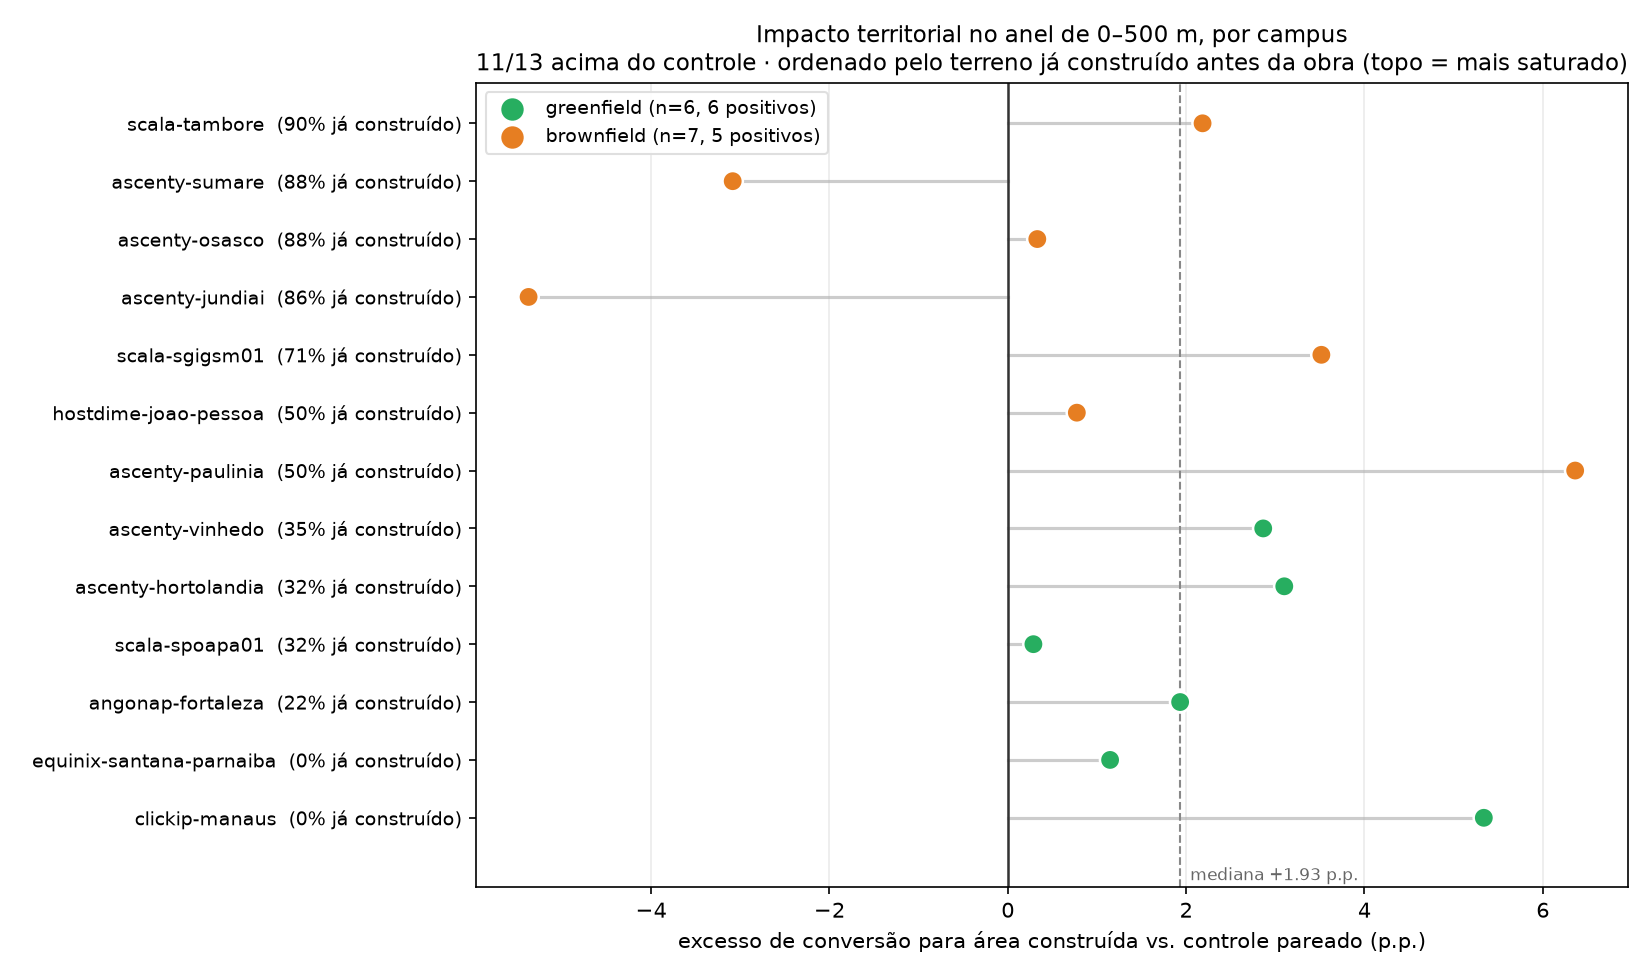

In [4]:
display(Image(filename=str(FIG / "fig_01_boletim.png")))

Repare na ordenação: os campi estão ordenados pelo **quanto do terreno já era construído antes da
obra**. Os dois únicos negativos do estudo — `ascenty-jundiai` (−5,37 p.p.) e `ascenty-sumare`
(−3,08 p.p.) — são os mais saturados, com 86% e 88% já construídos. Num sítio saturado sobra pouco
terreno convertível, e o excesso encolhe por motivo **mecânico**, não por ausência de efeito.

### O boletim campus a campus

In [5]:
cols = ["site_id", "municipio", "uf", "x_tipo_sitio", "x_pct_ja_construida",
        "efeito_construcao_0_500m", "score_construcao_0_500m",
        "efeito_vegetacao_0_500m", "efeito_temperatura"]
por_campus[cols].rename(columns={
    "x_tipo_sitio": "tipo_sitio",
    "x_pct_ja_construida": "pct_ja_construido",
    "efeito_construcao_0_500m": "constr_0-500m_pp",
    "score_construcao_0_500m": "score_0_100",
    "efeito_vegetacao_0_500m": "veget_0-500m_pp",
    "efeito_temperatura": "lst_C",
})

,site_id,municipio,uf,tipo_sitio,pct_ja_construido,constr_0-500m_pp,score_0_100,veget_0-500m_pp,lst_C
0,ascenty-paulinia,Paulínia,SP,brownfield,50.00,6.363,100.0,6.252,-0.009
1,ascenty-maracanau,Maracanaú,CE,NaN,NaN,6.084,92.9,5.239,0.562
2,clickip-manaus,Manaus,AM,greenfield,0.00,5.339,85.7,2.319,-2.719
3,scala-sgigsm01,São João de Meriti,RJ,brownfield,71.26,3.517,78.6,0.280,-0.823
4,ascenty-hortolandia,Hortolândia,SP,greenfield,31.84,3.101,71.4,3.101,0.352
5,ascenty-vinhedo,Vinhedo,SP,greenfield,35.48,2.865,64.3,2.685,-0.408
6,scala-tambore,Barueri,SP,brownfield,89.74,2.185,57.1,2.185,-0.607
7,angonap-fortaleza,Fortaleza,CE,greenfield,22.22,1.933,50.0,-0.222,0.421
8,equinix-santana-parnaiba,Santana de Parnaíba,SP,greenfield,0.00,1.148,42.9,0.907,-0.321
9,hostdime-joao-pessoa,João Pessoa,PB,brownfield,50.00,0.775,35.7,0.664,-0.470


> O `score_0_100` é **posto percentual dentro dos 14 casos medidos** — posição relativa, não medida
> absoluta de dano. Um campus com score 100 é o que mais converteu *nesta amostra*, não "impacto
> máximo possível".

### Por que a temperatura não entra como afirmação

Coletamos LST para os 30 pontos (204/204, equilibrado). O resultado é nulo: 6/15 aqueceram mais que
o controle, p=0,61. **Mas o nulo não informa nada**, e a figura abaixo mostra por quê — o painel da
direita prova que o dado está fisicamente sadio (r=0,49 entre LST e área construída), então a
ausência de sinal é falta de escala, não dado ruim:

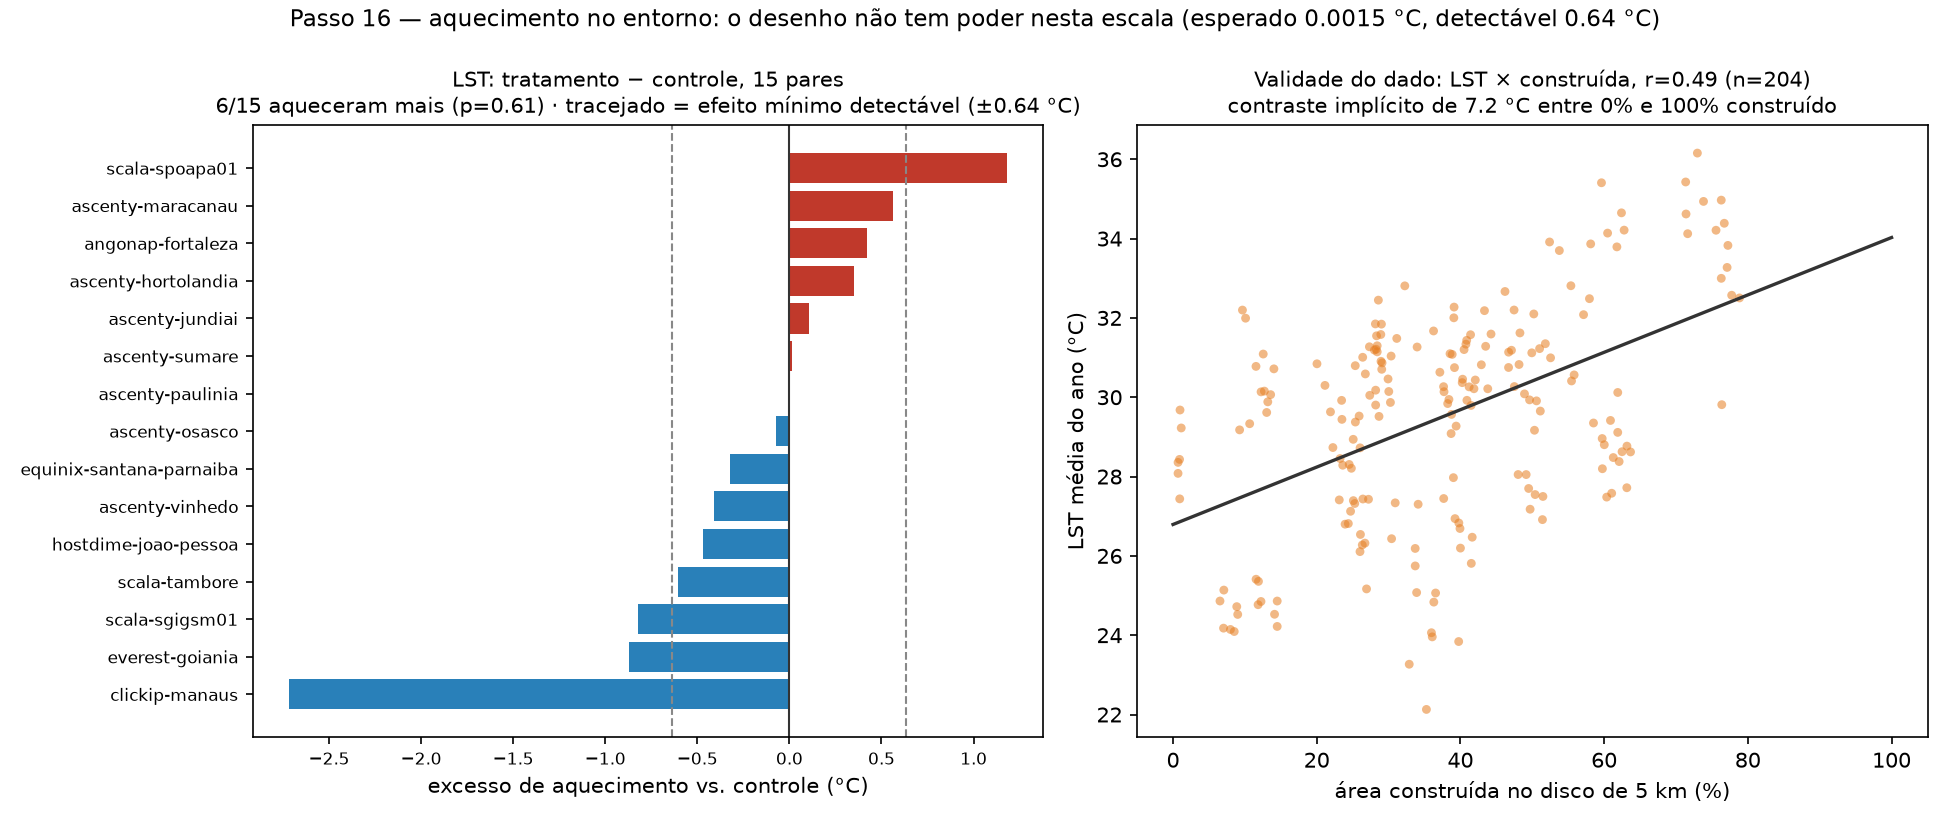

efeito esperado no disco de 5 km : 0.0015 °C
efeito mínimo detectável        : 0.636 °C
razão                           : 427x

MODIS tem 1 km de resolução e o efeito vive num anel de 500 m — menor que um pixel.
Responder isso de verdade exige a banda termal do Landsat (30 m).


In [6]:
display(Image(filename=str(REPO_ROOT / "dados-modelo-impacto" / "raw" / "controles-rf" /
                           "figuras" / "fig_10_lst_did.png")))

poder = pd.read_csv(REPO_ROOT / "dados-modelo-impacto" / "raw" / "controles-rf" / "lst_did_poder.csv")
print(f"efeito esperado no disco de 5 km : {poder.efeito_esperado_no_disco_c.iloc[0]:.4f} °C")
print(f"efeito mínimo detectável        : {poder.efeito_minimo_detectavel_c.iloc[0]:.3f} °C")
print(f"razão                           : {poder.razao_mde_sobre_esperado.iloc[0]:.0f}x")
print("\nMODIS tem 1 km de resolução e o efeito vive num anel de 500 m — menor que um pixel.")
print("Responder isso de verdade exige a banda termal do Landsat (30 m).")

---
## 2. Camada 2 — o que explica o tamanho do impacto?

O passo 15 da frente anterior achou uma regra de **uma variável** que funciona: sítios *greenfield*
(< 50% do footprint já construído) dão **6/6** pares positivos (p=0,016), contra 5/7 em *brownfield*.

A pergunta desta camada era a única que interessa depois disso:

> **alguma coisa bate `pct_ja_construida` sozinho?**

Testamos 13 modelos contra o baseline "prever a mediana", **todos por validação cruzada
leave-one-out** com N=13. Todo número abaixo é fora-da-amostra.

In [7]:
modelos

,modelo,n_parametros_livres,loocv_mae_pp,loocv_r2,loocv_rmse_pp,bate_baseline
0,ols_1f::x_pre_lst_media_celsius,2,2.319,-0.030,3.075,True
1,ols_1f::x_pct_ja_construida,2,2.608,-0.075,3.141,True
2,arvore_d1::terreno,2,2.681,-0.075,3.141,True
3,ridge_2f::terreno+vegetacao,3,2.535,-0.088,3.160,True
4,regra_grupo::x_bioma,3,2.540,-0.145,3.242,False
5,baseline_mediana,0,2.513,-0.145,3.241,False
6,ridge_3f::+footprint,4,2.678,-0.160,3.263,False
7,regra_grupo::x_tipo_sitio,2,2.630,-0.164,3.268,False
8,ols_1f::x_pre_prop_construida_urbana,2,2.487,-0.206,3.326,False
9,regra_grupo::x_regiao,4,2.641,-0.256,3.395,False


**Todos os 13 modelos têm R² negativo** — todos preveem pior que simplesmente dizer "a média" para
todo mundo. Nenhuma feature isolada atinge significância:

In [8]:
features[["feature", "n", "spearman_rho", "spearman_p"]].dropna(subset=["spearman_rho"])

,feature,n,spearman_rho,spearman_p
0,x_pct_ja_construida,13,-0.314,0.2960
1,x_pre_prop_construida_urbana,13,0.286,0.3440
2,x_pre_prop_vegetacao_densa,13,-0.324,0.2799
3,x_pre_prop_vegetacao_rala,13,0.066,0.8305
4,x_area_footprint_ha,13,0.170,0.5780
5,x_n_predios,13,-0.179,0.5587
6,x_pre_lst_media_celsius,13,0.533,0.0607


### O teste que fecha a porta

Com 13 pontos e ~8 features candidatas, o melhor R² de um sorteio de **ruído puro** é
surpreendentemente alto. Embaralhamos o alvo 999 vezes e refizemos a busca inteira, para medir
exatamente essa inflação por garimpo:

In [9]:
for c, v in permutacao.iloc[0].items():
    print(f"{c:32s} {v}")

melhor_modelo_observado          ols_1f::x_pre_lst_media_celsius
loocv_r2_observado               -0.03
n_permutacoes                    999
r2_maximo_mediano_sob_ruido      -0.01
r2_maximo_p95_sob_ruido          0.361
p_permutacao                     0.5335
leitura                          NÃO se distingue do melhor resultado que ruído puro produziria na mesma busca — não há poder preditivo demonstrado


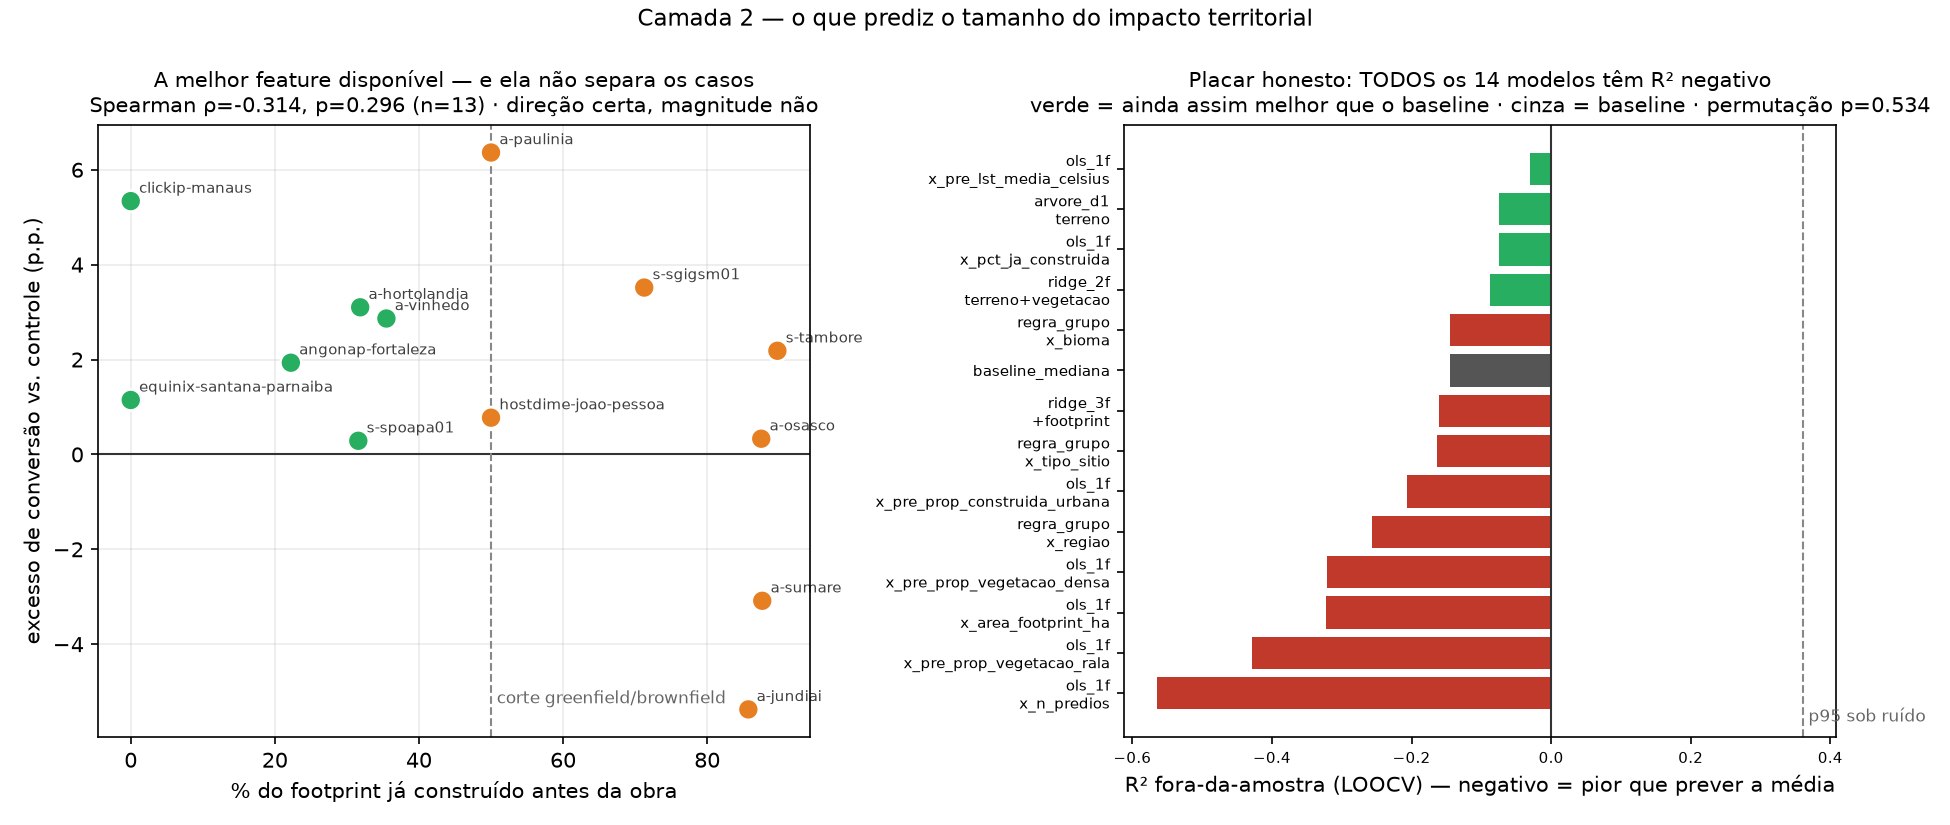

In [10]:
display(Image(filename=str(FIG / "fig_02_explicacao.png")))

### Isto contradiz o achado greenfield/brownfield? Não.

São duas perguntas diferentes, e **as duas respostas estão certas**:

| pergunta | teste | resposta |
|---|---|---|
| a **direção** é consistente? | teste de sinal | **sim** — 6/6 greenfield positivos, p=0,016 |
| a **magnitude** é predizível? | R² LOOCV | **não** — negativo em todos os modelos |

Um teste de sinal pergunta se o efeito aponta para o mesmo lado. Uma regressão pergunta se dá para
prever *o quanto*. Com 13 casos muito heterogêneos — um campus de 400 MW e um prédio de 3 MW,
Manaus e Porto Alegre — a primeira resposta se sustenta e a segunda não.

É exatamente o que o README da frente anterior já suspeitava ao escrever *"a leitura defensável é a
do padrão, não a do coeficiente"*. Agora está medido.

---
## 3. Camada 3 — a projeção (demo)

Como a regressão de magnitude falhou, projetar um site novo **não pode devolver um número**.
Devolve o que sítios comparáveis de fato produziram — uma previsão de **classe de referência**.

Ela continua válida quando a regressão individual falha, porque não afirma nada sobre o caso
específico: afirma sobre a taxa-base do grupo.

In [11]:
classes_ref

,classe_referencia,n,n_positivo,frac_positivo,mediana_pp,p15_pp,p85_pp,min_pp,max_pp
0,greenfield,6,6,1.000,2.399,0.933,3.661,0.288,5.339
1,brownfield,7,5,0.714,0.775,-3.314,3.802,-5.374,6.363
2,amostra_completa,13,11,0.846,1.933,-0.387,3.881,-5.374,6.363


### Como isso é validado

Intervalo não se valida por R². Valida-se por **cobertura**: deixando cada campus de fora, a faixa
projetada pelos outros 12 contém o valor observado?

In [12]:
validacao[["estrategia", "cobertura_faixa_15_85", "cobertura_nominal",
           "largura_mediana_pp", "recomendada", "leitura"]]

,estrategia,cobertura_faixa_15_85,cobertura_nominal,largura_mediana_pp,recomendada,leitura
0,condicionada_no_tipo_de_sitio,0.462,0.7,4.752,False,condicionar estreita a faixa em só +0.30 p.p. ...
1,classe_unica,0.692,0.7,5.048,True,cobertura 69% contra nominal 70% — calibrada; ...


**Resultado contraintuitivo e importante:** condicionar em greenfield/brownfield **piora** o
intervalo — derruba a cobertura de 69% para 46% e estreita só 0,3 p.p. Com subgrupos de n=6 e n=7
os percentis ficam instáveis.

Ou seja: o achado direcional de greenfield vale, **o intervalo condicionado não**. Duas conclusões
que parecem contraditórias e não são — e que só aparecem porque validamos as duas coisas
separadamente.

### A demo — troque o número e rode de novo

In [13]:
import importlib
import projecao_demo  # noqa  (helper fino em modelo-impacto-score/scripts/)
importlib.reload(projecao_demo)

# >>> TROQUE AQUI: % do terreno do footprint já construído antes da obra (0 a 100)
projecao_demo.projetar_e_mostrar(15)

site com 15% do terreno já construído  ->  greenfield
  direção   : 6/6 dos análogos greenfield converteram MAIS que seu controle (100%)
  magnitude : faixa 15–85% de -0.39 a +3.88 p.p.  ·  mediana +1.93 p.p.


{'classe': 'greenfield',
 'direcao': {'classe_referencia': 'greenfield',
  'n': 6,
  'n_positivo': 6,
  'frac_positivo': 1.0,
  'mediana_pp': 2.399,
  'p15_pp': 0.933,
  'p85_pp': 3.661,
  'min_pp': 0.288,
  'max_pp': 5.339},
 'magnitude': {'classe_referencia': 'amostra_completa',
  'n': 13,
  'n_positivo': 11,
  'frac_positivo': 0.846,
  'mediana_pp': 1.933,
  'p15_pp': -0.387,
  'p85_pp': 3.881,
  'min_pp': -5.374,
  'max_pp': 6.363}}

In [14]:
# Alguns cenários lado a lado
for pct in (0, 25, 50, 75, 90):
    projecao_demo.projetar_e_mostrar(pct)
    print()

site com 0% do terreno já construído  ->  greenfield
  direção   : 6/6 dos análogos greenfield converteram MAIS que seu controle (100%)
  magnitude : faixa 15–85% de -0.39 a +3.88 p.p.  ·  mediana +1.93 p.p.

site com 25% do terreno já construído  ->  greenfield
  direção   : 6/6 dos análogos greenfield converteram MAIS que seu controle (100%)
  magnitude : faixa 15–85% de -0.39 a +3.88 p.p.  ·  mediana +1.93 p.p.

site com 50% do terreno já construído  ->  brownfield
  direção   : 5/7 dos análogos brownfield converteram MAIS que seu controle (71%)
  magnitude : faixa 15–85% de -0.39 a +3.88 p.p.  ·  mediana +1.93 p.p.

site com 75% do terreno já construído  ->  brownfield
  direção   : 5/7 dos análogos brownfield converteram MAIS que seu controle (71%)
  magnitude : faixa 15–85% de -0.39 a +3.88 p.p.  ·  mediana +1.93 p.p.

site com 90% do terreno já construído  ->  brownfield
  direção   : 5/7 dos análogos brownfield converteram MAIS que seu controle (71%)
  magnitude : faixa 15–85% 

> **Repare que a faixa de magnitude é a MESMA nos cinco cenários — e isso não é bug, é o
> resultado.** Só a *direção* muda com a entrada (100% dos greenfield positivos contra 71% dos
> brownfield), porque é a única coisa que as features preveem. A magnitude não muda porque
> **nada na camada 2 conseguiu prevê-la**, então a faixa honesta é a da amostra inteira — a única
> com cobertura calibrada.
>
> Uma ferramenta que devolvesse faixas diferentes por cenário aqui estaria inventando precisão que
> os dados não sustentam. Este é o comportamento correto, e é o que separa esta demo de um
> dashboard bonito que mente.

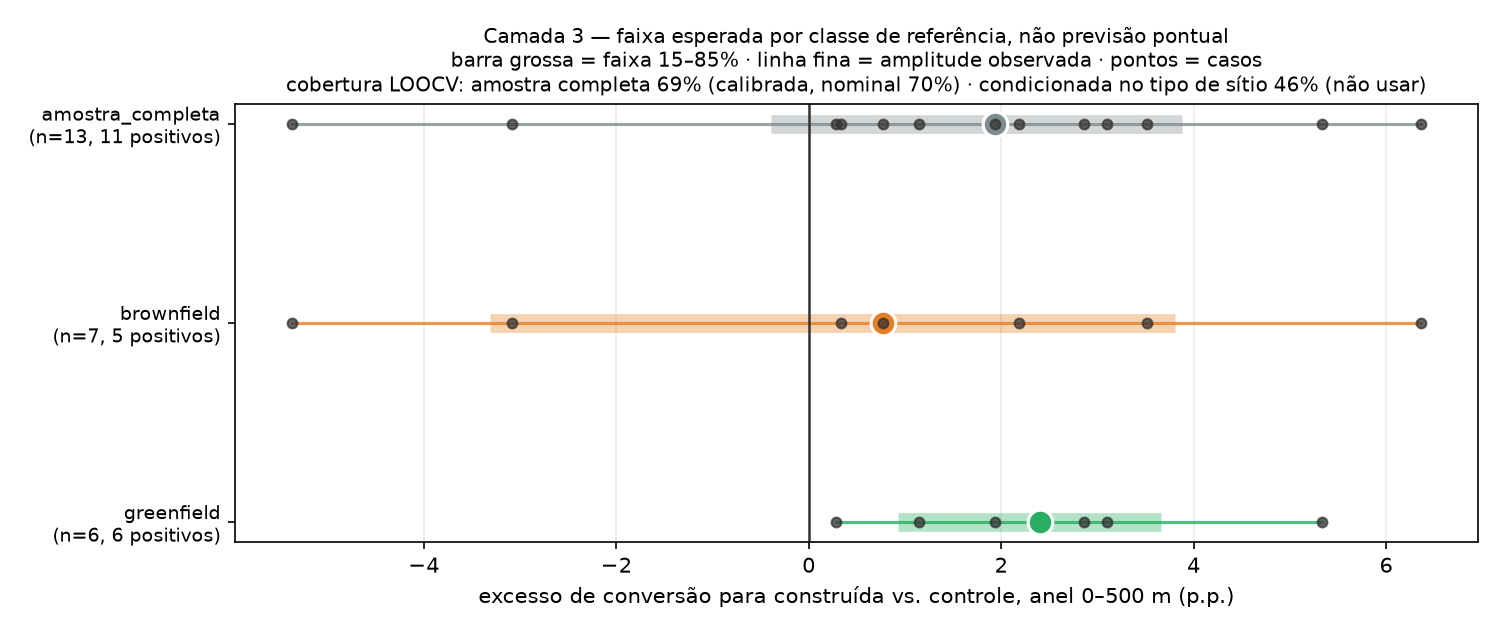

In [15]:
display(Image(filename=str(FIG / "fig_03_projecao.png")))

---
## 4. Limitações — as que eu levantaria antes que perguntem

- **N=15**, e 2 dos pares vão na direção contrária (ambos explicados pela saturação do sítio).
- **`pct_ja_construida` só existe para 13 campi** — 2 sem footprint no OpenStreetMap.
- **O corte de 50% greenfield/brownfield foi escolhido depois de ver os dados.** O script varre 7
  limiares e publica todos; greenfield fica 100% positivo em toda a faixa de 40% a 80%. O teste
  contínuo equivalente (Spearman −0,31) tem direção consistente e magnitude fraca.
- **Janela pós-obra curta:** pela coluna `fase`, só 7 dos 15 campi têm ≥2 anos pré *e* ≥2 pós. Por
  isso tudo aqui usa a convenção "2 primeiros × 2 últimos anos da janela", que preserva 14–15
  pares. **É a pergunta que eu faria no lugar da banca.**
- **Sem série de precipitação.** Qualquer afirmação sobre vegetação carrega o confundidor climático
  não controlado.
- **Emprego, PIB e população não entram em eixo nenhum** — são municipais, e os pares têm portes
  municipais de razão 0,03 a 15,0. Servem como contexto, nunca como evidência.
- **Não é inferência causal formal.** É padrão consistente contra grupo de controle, com
  pré-tendências paralelas verificadas (6/14, p=0,79).

---
## 5. A conclusão em uma frase

> Em **12 dos 14** data centers com par válido, o anel de 500 m ao redor converteu para área
> construída mais do que um terreno pareado sem data center — excesso mediano de **2,06 p.p.**,
> **p=0,0065**. O efeito decai com a distância e desaparece depois de 1 km, é localizado e não
> regional, e as tendências pré-obra eram paralelas. A **magnitude**, porém, **não é predizível**
> a partir das features disponíveis: nenhum dos 13 modelos testados supera o baseline sob validação
> cruzada. O que se sustenta é o padrão, não o coeficiente.

Relatório completo: `modelo-impacto-score/reports/relatorio-impacto.md`